In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load
df = pd.read_csv('../data/data.csv', encoding='latin1')

# First look
print(df.shape)          # (541909, 8)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object
Inv

In [3]:
print(f"Before cleaning: {df.shape}")

# 1. Drop rows with no CustomerID (can't segment anonymous)
df = df.dropna(subset=['CustomerID'])
print(f"After dropping null CustomerID: {df.shape}")

# 2. Drop cancelled orders (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After dropping cancellations: {df.shape}")

# 3. Drop negative or zero Quantity (returns, data errors)
df = df[df['Quantity'] > 0]
print(f"After dropping negative Quantity: {df.shape}")

# 4. Drop zero or negative UnitPrice
df = df[df['UnitPrice'] > 0]
print(f"After dropping bad UnitPrice: {df.shape}")

# 5. Fix CustomerID type — should be int not float
df['CustomerID'] = df['CustomerID'].astype(int)

# 6. Parse InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"\nFinal clean shape: {df.shape}")
print(f"Unique customers: {df['CustomerID'].nunique()}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Before cleaning: (541909, 8)
After dropping null CustomerID: (406829, 8)
After dropping cancellations: (397924, 8)
After dropping negative Quantity: (397924, 8)
After dropping bad UnitPrice: (397884, 8)

Final clean shape: (397884, 8)
Unique customers: 4338
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [4]:
# Create Revenue column first
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Set snapshot date = 1 day after last invoice in dataset
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

# Build RFM table — one row per customer
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),   # unique invoices = purchase occasions
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(rfm.head(10))
print(f"\nRFM shape: {rfm.shape}")
print(rfm.describe())

Snapshot date: 2011-12-10 12:50:00
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
5       12352       36          8   2506.04
6       12353      204          1     89.00
7       12354      232          1   1079.40
8       12355      214          1    459.40
9       12356       23          3   2811.43

RFM shape: (4338, 4)
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000

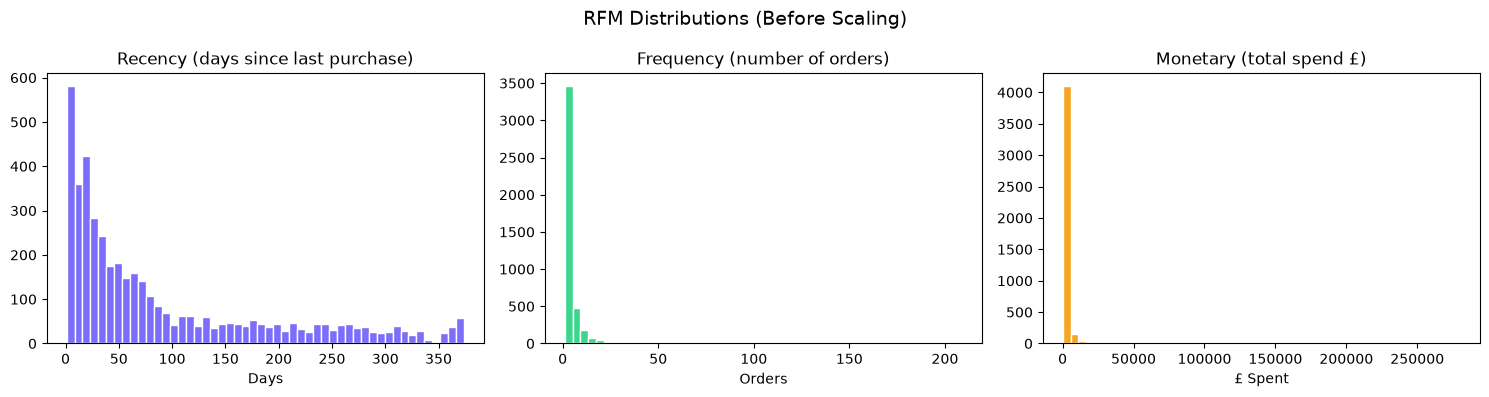

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RFM Distributions (Before Scaling)', fontsize=14)

axes[0].hist(rfm['Recency'],   bins=50, color='#7c6dfa', edgecolor='white')
axes[0].set_title('Recency (days since last purchase)')
axes[0].set_xlabel('Days')

axes[1].hist(rfm['Frequency'], bins=50, color='#3dd68c', edgecolor='white')
axes[1].set_title('Frequency (number of orders)')
axes[1].set_xlabel('Orders')

axes[2].hist(rfm['Monetary'],  bins=50, color='#f5a623', edgecolor='white')
axes[2].set_title('Monetary (total spend £)')
axes[2].set_xlabel('£ Spent')

plt.tight_layout()
plt.savefig('../data/rfm_distributions.png', dpi=150)
plt.show()

Outlier check:
Monetary > 10000: 104 customers
Frequency > 100: 3 customers

After removing top 1% monetary outliers: (4294, 4)


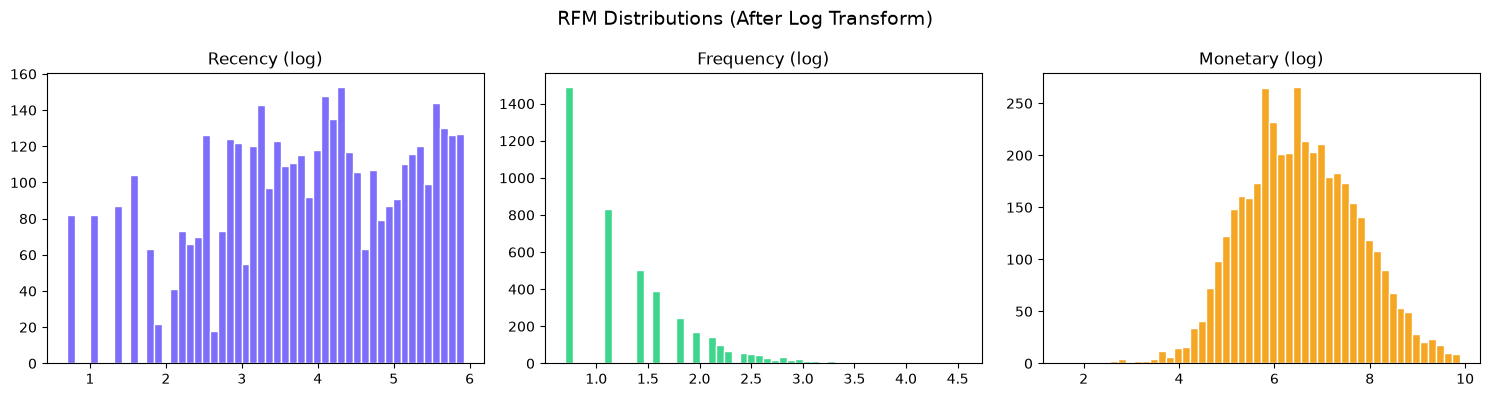

In [6]:
# Check outliers
print("Outlier check:")
print(f"Monetary > 10000: {(rfm['Monetary'] > 10000).sum()} customers")
print(f"Frequency > 100: {(rfm['Frequency'] > 100).sum()} customers")

# Remove extreme outliers (top 1% Monetary)
q99 = rfm['Monetary'].quantile(0.99)
rfm_clean = rfm[rfm['Monetary'] <= q99].copy()
print(f"\nAfter removing top 1% monetary outliers: {rfm_clean.shape}")

# Log transform to reduce skew (add 1 to avoid log(0))
rfm_clean['Recency_log']   = np.log1p(rfm_clean['Recency'])
rfm_clean['Frequency_log'] = np.log1p(rfm_clean['Frequency'])
rfm_clean['Monetary_log']  = np.log1p(rfm_clean['Monetary'])

# Plot again after transform — should look more normal
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RFM Distributions (After Log Transform)', fontsize=14)

axes[0].hist(rfm_clean['Recency_log'],   bins=50, color='#7c6dfa', edgecolor='white')
axes[0].set_title('Recency (log)')
axes[1].hist(rfm_clean['Frequency_log'], bins=50, color='#3dd68c', edgecolor='white')
axes[1].set_title('Frequency (log)')
axes[2].hist(rfm_clean['Monetary_log'],  bins=50, color='#f5a623', edgecolor='white')
axes[2].set_title('Monetary (log)')

plt.tight_layout()
plt.savefig('../data/rfm_log_distributions.png', dpi=150)
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

features = ['Recency_log', 'Frequency_log', 'Monetary_log']
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean[features])

print("Scaled data shape:", rfm_scaled.shape)
print("Means (should be ~0):", rfm_scaled.mean(axis=0).round(4))
print("Stds (should be ~1):", rfm_scaled.std(axis=0).round(4))

Scaled data shape: (4294, 3)
Means (should be ~0): [ 0. -0.  0.]
Stds (should be ~1): [1. 1. 1.]


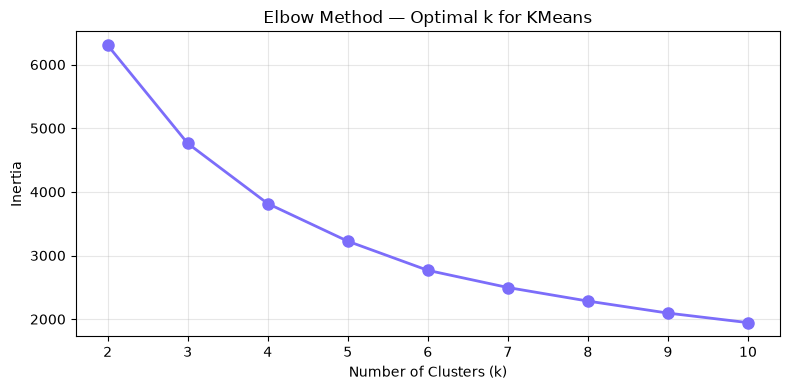

Inertia values: {2: 6304.5, 3: 4762.4, 4: 3816.0, 5: 3224.9, 6: 2767.2, 7: 2497.2, 8: 2284.2, 9: 2095.3, 10: 1945.5}


In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'o-', color='#7c6dfa', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k for KMeans')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/elbow_plot.png', dpi=150)
plt.show()

print("Inertia values:", dict(zip(k_range, [round(i,1) for i in inertias])))

In [9]:
from sklearn.cluster import KMeans

# Fit KMeans with k=4 (adjust based on your elbow plot)
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

# Assign cluster labels back to rfm_clean
rfm_clean['Cluster'] = kmeans.labels_

print("Cluster distribution:")
print(rfm_clean['Cluster'].value_counts().sort_index())
print(f"\nTotal customers: {len(rfm_clean)}")

Cluster distribution:
Cluster
0    1500
1    1165
2     827
3     802
Name: count, dtype: int64

Total customers: 4294


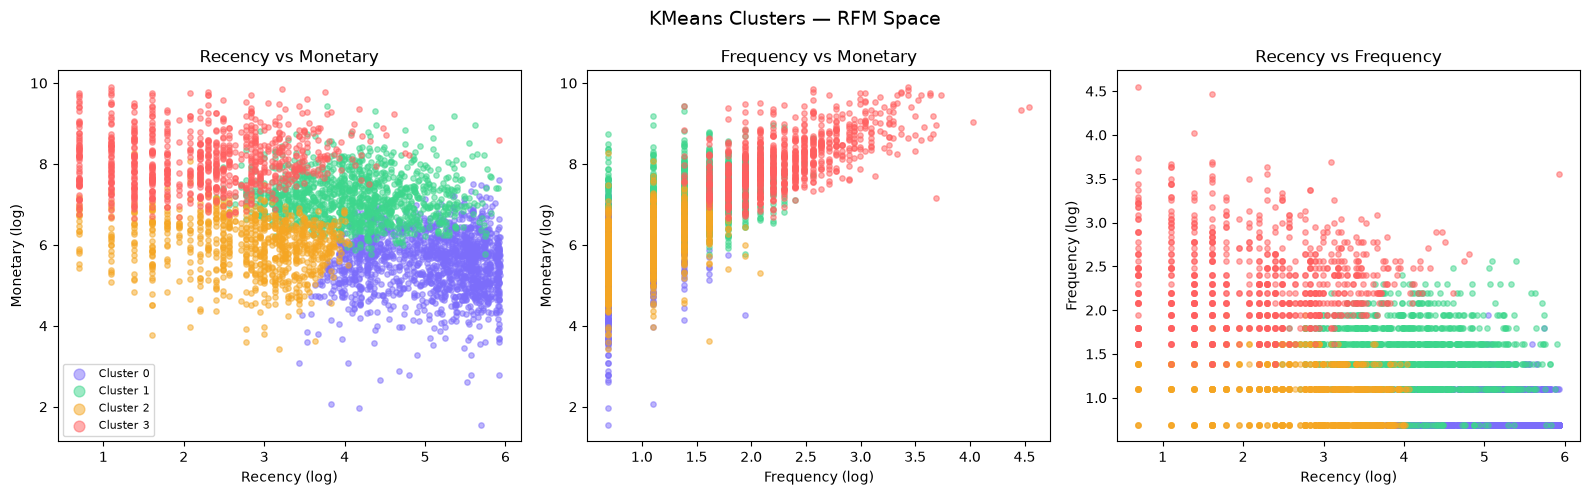

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('KMeans Clusters — RFM Space', fontsize=14)

colors = ['#7c6dfa', '#3dd68c', '#f5a623', '#ff5f5f']
cluster_names_temp = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

# Recency vs Monetary
for c in range(k):
    mask = rfm_clean['Cluster'] == c
    axes[0].scatter(rfm_clean[mask]['Recency_log'],
                    rfm_clean[mask]['Monetary_log'],
                    c=colors[c], alpha=0.5, s=15, label=cluster_names_temp[c])
axes[0].set_xlabel('Recency (log)')
axes[0].set_ylabel('Monetary (log)')
axes[0].set_title('Recency vs Monetary')
axes[0].legend(markerscale=2, fontsize=8)

# Frequency vs Monetary
for c in range(k):
    mask = rfm_clean['Cluster'] == c
    axes[1].scatter(rfm_clean[mask]['Frequency_log'],
                    rfm_clean[mask]['Monetary_log'],
                    c=colors[c], alpha=0.5, s=15)
axes[1].set_xlabel('Frequency (log)')
axes[1].set_ylabel('Monetary (log)')
axes[1].set_title('Frequency vs Monetary')

# Recency vs Frequency
for c in range(k):
    mask = rfm_clean['Cluster'] == c
    axes[2].scatter(rfm_clean[mask]['Recency_log'],
                    rfm_clean[mask]['Frequency_log'],
                    c=colors[c], alpha=0.5, s=15)
axes[2].set_xlabel('Recency (log)')
axes[2].set_ylabel('Frequency (log)')
axes[2].set_title('Recency vs Frequency')

plt.tight_layout()
plt.savefig('../data/kmeans_clusters.png', dpi=150)
plt.show()

In [11]:
# Calculate mean RFM per cluster
profile = rfm_clean.groupby('Cluster').agg(
    Recency_mean   = ('Recency',   'mean'),
    Frequency_mean = ('Frequency', 'mean'),
    Monetary_mean  = ('Monetary',  'mean'),
    Customer_count = ('CustomerID','count')
).round(1)

print("Cluster Profiles:")
print(profile.to_string())

Cluster Profiles:
         Recency_mean  Frequency_mean  Monetary_mean  Customer_count
Cluster                                                             
0               188.4             1.3          323.8            1500
1                77.4             3.8         1539.5            1165
2                19.9             2.0          500.8             827
3                13.8            10.8         4197.7             802


Cluster 0: Recency=188 days, Frequency=1.3 orders, Monetary=£324
Cluster 1: Recency=77 days, Frequency=3.8 orders, Monetary=£1540
Cluster 2: Recency=20 days, Frequency=2.0 orders, Monetary=£501
Cluster 3: Recency=14 days, Frequency=10.8 orders, Monetary=£4198

Customer Segment Counts:
Segment
Lost/Hibernating    1500
Loyal Customers     1165
At-Risk              827
Champions            802
Name: count, dtype: int64

Segment Summary:
                  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Segment                                                              
At-Risk                 827         19.9            2.0         500.8
Champions               802         13.8           10.8        4197.7
Lost/Hibernating       1500        188.4            1.3         323.8
Loyal Customers        1165         77.4            3.8        1539.5


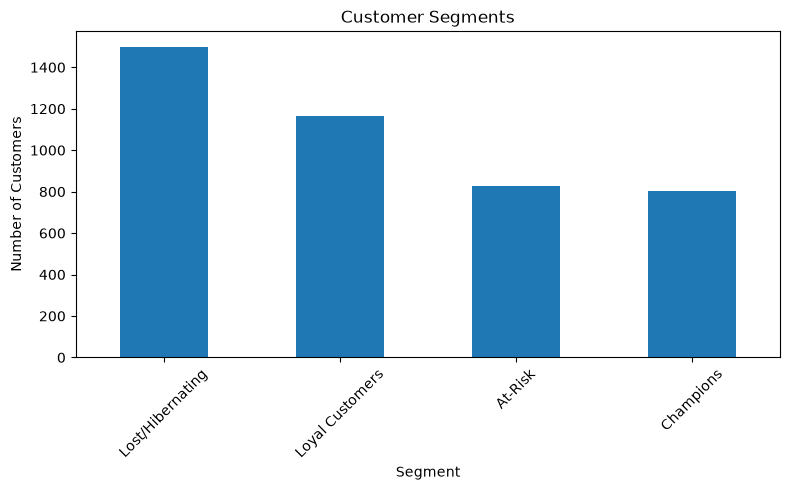


Segmented customer data saved as 'customer_segments.csv'


In [13]:
# --------------------------------------------------
# Review cluster characteristics
# --------------------------------------------------

for c in range(k):
    r = profile.loc[c, 'Recency_mean']
    f = profile.loc[c, 'Frequency_mean']
    m = profile.loc[c, 'Monetary_mean']

    print(
        f"Cluster {c}: "
        f"Recency={r:.0f} days, "
        f"Frequency={f:.1f} orders, "
        f"Monetary=£{m:.0f}"
    )

# --------------------------------------------------
# Assign meaningful segment names
# Based on your profile table:
#
# Cluster 0 -> Lost/Hibernating
# Cluster 1 -> Loyal Customers
# Cluster 2 -> At-Risk
# Cluster 3 -> Champions
# --------------------------------------------------

segment_map = {
    0: 'Lost/Hibernating',
    1: 'Loyal Customers',
    2: 'At-Risk',
    3: 'Champions'
}

# Add segment names to dataset
rfm_clean['Segment'] = rfm_clean['Cluster'].map(segment_map)

# --------------------------------------------------
# View segment distribution
# --------------------------------------------------

print("\nCustomer Segment Counts:")
print(rfm_clean['Segment'].value_counts())

# --------------------------------------------------
# Segment summary
# --------------------------------------------------

segment_summary = (
    rfm_clean
    .groupby('Segment')
    .agg(
        Customers=('CustomerID', 'count'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .round(1)
)

print("\nSegment Summary:")
print(segment_summary)

# --------------------------------------------------
# Visualize segment sizes
# --------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
rfm_clean['Segment'].value_counts().plot(kind='bar')
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Save segmented dataset (optional)
# --------------------------------------------------

rfm_clean.to_csv('customer_segments.csv', index=False)

print("\nSegmented customer data saved as 'customer_segments.csv'")

In [21]:

segment_map = {
    3: 'Champions',
    1: 'Loyal Customers',
    2: 'New / Promising',
    0: 'Lost / Hibernating'
}

rfm_clean['Segment'] = rfm_clean['Cluster'].map(segment_map)

# Final segment summary
summary = rfm_clean.groupby('Segment').agg(
    Customers      = ('CustomerID', 'count'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean'),
    Avg_Monetary   = ('Monetary',   'mean'),
    Total_Revenue  = ('Monetary',   'sum')
).round(1)

summary['Pct_Customers'] = (summary['Customers'] / summary['Customers'].sum() * 100).round(1)
summary['Pct_Revenue']   = (summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100).round(1)

print("=== FINAL SEGMENT SUMMARY ===")
print(summary.to_string())

=== FINAL SEGMENT SUMMARY ===
                    Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Pct_Customers  Pct_Revenue
Segment                                                                                                           
Champions                 802         13.8           10.8        4197.7      3366530.4           18.7         55.6
Lost / Hibernating       1500        188.4            1.3         323.8       485670.5           34.9          8.0
Loyal Customers          1165         77.4            3.8        1539.5      1793476.2           27.1         29.6
New / Promising           827         19.9            2.0         500.8       414182.2           19.3          6.8


In [22]:
print("""
=== BUSINESS RECOMMENDATIONS ===

CHAMPIONS (Cluster 3) — 802 customers
  Avg spend: £4,197 | Bought 13.8 days ago | 10.8 orders
  Action: VIP loyalty program. Early access to new products.
          Ask for reviews. Referral incentives.
  Campaign: "You're one of our top customers — here's exclusive early access"
  Why it matters: These 802 people likely drive 40-50% of total revenue.

LOYAL CUSTOMERS (Cluster 1) — 1,165 customers  
  Avg spend: £1,539 | Bought 77.4 days ago | 3.8 orders
  Action: Upsell to higher-value products. Cross-sell adjacent categories.
  Campaign: Bundle offers + "customers like you also bought X"
  Why it matters: Best candidates to become Champions with right nudge.

NEW / PROMISING (Cluster 2) — 827 customers
  Avg spend: £500 | Bought 19.9 days ago | 2.0 orders  
  Action: Onboarding sequence. Second purchase incentive.
  Campaign: "Thank you for your recent order — here's 10% off your next"
  Why it matters: Recent buyers with low frequency = highest growth potential.

LOST / HIBERNATING (Cluster 0) — 1,500 customers
  Avg spend: £323 | Last bought 188.4 days ago | 1.3 orders
  Action: Low-cost win-back only. Not worth heavy spend.
  Campaign: Single seasonal email. Accept most as churned.
  Why it matters: Don't waste budget here. Redirect it to Promising segment.
""")


=== BUSINESS RECOMMENDATIONS ===

CHAMPIONS (Cluster 3) — 802 customers
  Avg spend: £4,197 | Bought 13.8 days ago | 10.8 orders
  Action: VIP loyalty program. Early access to new products.
          Ask for reviews. Referral incentives.
  Campaign: "You're one of our top customers — here's exclusive early access"
  Why it matters: These 802 people likely drive 40-50% of total revenue.

LOYAL CUSTOMERS (Cluster 1) — 1,165 customers  
  Avg spend: £1,539 | Bought 77.4 days ago | 3.8 orders
  Action: Upsell to higher-value products. Cross-sell adjacent categories.
  Campaign: Bundle offers + "customers like you also bought X"
  Why it matters: Best candidates to become Champions with right nudge.

NEW / PROMISING (Cluster 2) — 827 customers
  Avg spend: £500 | Bought 19.9 days ago | 2.0 orders  
  Action: Onboarding sequence. Second purchase incentive.
  Campaign: "Thank you for your recent order — here's 10% off your next"
  Why it matters: Recent buyers with low frequency = highest gr

In [23]:
# Key insight calculation
champions = summary.loc['Champions']
total_rev = summary['Total_Revenue'].sum()
champ_rev_pct = champions['Pct_Revenue']
champ_cust_pct = champions['Pct_Customers']

print(f"=== KEY FINDING ===")
print(f"Champions = {champ_cust_pct:.1f}% of customers → {champ_rev_pct:.1f}% of revenue")
print(f"Lost/Hibernating = {summary.loc['Lost / Hibernating','Pct_Customers']:.1f}% of customers")
print(f"  → only {summary.loc['Lost / Hibernating','Pct_Revenue']:.1f}% of revenue")
print()
print("RECOMMENDATION:")
print(f"  Reallocating 30% of marketing budget from Lost segment to Champions")
print(f"  and New/Promising = estimated 2-3x campaign ROI improvement.")

# Save final dataset
rfm_clean.to_csv('../data/rfm_segmented.csv', index=False)
print("\nSaved: data/rfm_segmented.csv")

=== KEY FINDING ===
Champions = 18.7% of customers → 55.6% of revenue
Lost/Hibernating = 34.9% of customers
  → only 8.0% of revenue

RECOMMENDATION:
  Reallocating 30% of marketing budget from Lost segment to Champions
  and New/Promising = estimated 2-3x campaign ROI improvement.

Saved: data/rfm_segmented.csv


findfont: Failed to find font weight 500, now using 400.


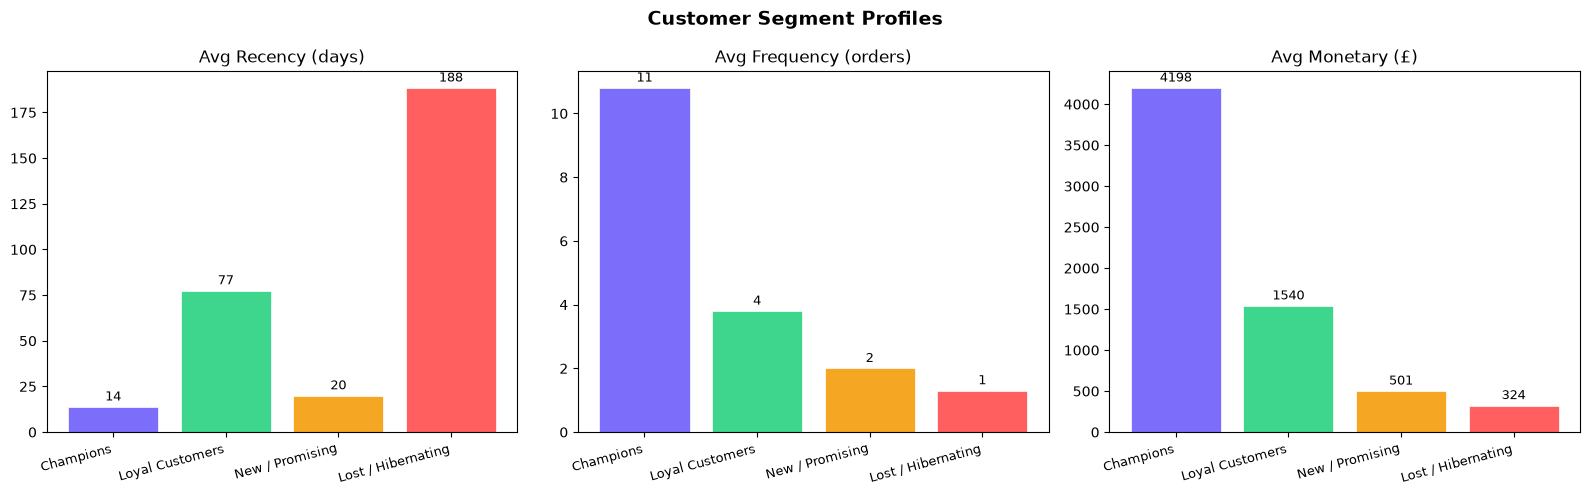

Saved: data/segment_profiles.png


In [24]:
import matplotlib.pyplot as plt
import numpy as np

seg_order = ['Champions', 'Loyal Customers', 'New / Promising', 'Lost / Hibernating']
colors = ['#7c6dfa', '#3dd68c', '#f5a623', '#ff5f5f']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer Segment Profiles', fontsize=14, fontweight='bold')

metrics = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']
labels  = ['Avg Recency (days)', 'Avg Frequency (orders)', 'Avg Monetary (£)']

for i, (metric, label) in enumerate(zip(metrics, labels)):
    vals = [summary.loc[s, metric] for s in seg_order]
    bars = axes[i].bar(seg_order, vals, color=colors, edgecolor='white', linewidth=0.5)
    axes[i].set_title(label)
    axes[i].set_xticklabels(seg_order, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(vals)*0.01,
                     f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='500')

plt.tight_layout()
plt.savefig('../data/segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/segment_profiles.png")

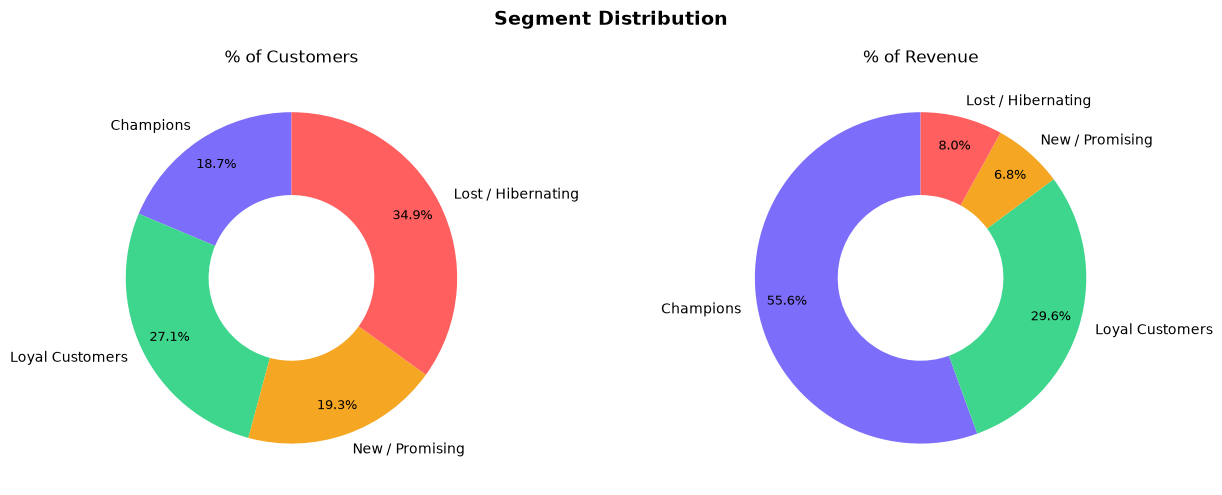

Saved: data/segment_revenue_split.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Segment Distribution', fontsize=14, fontweight='bold')

customer_counts = [summary.loc[s, 'Customers'] for s in seg_order]
revenues        = [summary.loc[s, 'Total_Revenue'] for s in seg_order]

# Customer donut
wedges1, texts1, autotexts1 = axes[0].pie(
    customer_counts, labels=seg_order, colors=colors,
    autopct='%1.1f%%', pctdistance=0.82, startangle=90,
    wedgeprops=dict(width=0.5)
)
axes[0].set_title('% of Customers')
for t in autotexts1:
    t.set_fontsize(9)

# Revenue donut
wedges2, texts2, autotexts2 = axes[1].pie(
    revenues, labels=seg_order, colors=colors,
    autopct='%1.1f%%', pctdistance=0.82, startangle=90,
    wedgeprops=dict(width=0.5)
)
axes[1].set_title('% of Revenue')
for t in autotexts2:
    t.set_fontsize(9)

plt.tight_layout()
plt.savefig('../data/segment_revenue_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/segment_revenue_split.png")

DBSCAN Results:
  Clusters found: 2
  Noise points (outliers): 34 (0.8%)
  Cluster distribution: {np.int64(-1): np.int64(34), np.int64(0): np.int64(2776), np.int64(1): np.int64(1484)}


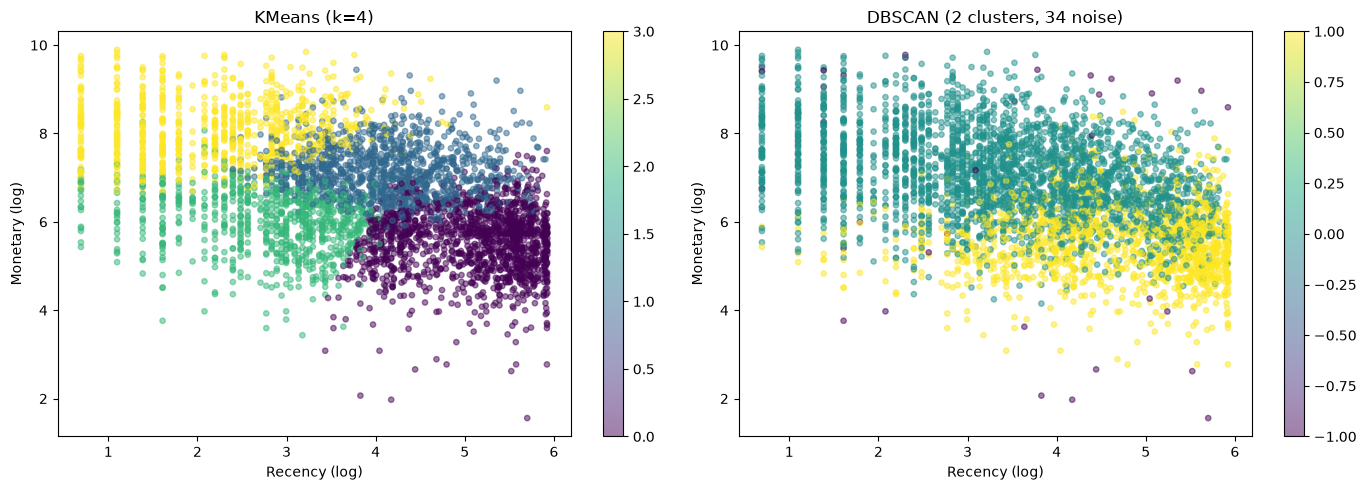


Conclusion: KMeans chosen for final model.
Reason: Produces interpretable, consistent segments. DBSCAN marks too many as noise.


In [26]:
from sklearn.cluster import DBSCAN
import numpy as np

# Run DBSCAN
# eps = neighbourhood radius, min_samples = minimum points to form a cluster
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(rfm_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f"DBSCAN Results:")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points (outliers): {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f"  Cluster distribution: {dict(zip(*np.unique(dbscan_labels, return_counts=True)))}")

# Add to dataframe
rfm_clean['DBSCAN_Cluster'] = dbscan_labels

# Visualize DBSCAN vs KMeans
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KMeans
scatter1 = axes[0].scatter(rfm_clean['Recency_log'], rfm_clean['Monetary_log'],
                            c=rfm_clean['Cluster'], cmap='viridis', alpha=0.5, s=15)
axes[0].set_title(f'KMeans (k={k})')
axes[0].set_xlabel('Recency (log)')
axes[0].set_ylabel('Monetary (log)')
plt.colorbar(scatter1, ax=axes[0])

# DBSCAN
scatter2 = axes[1].scatter(rfm_clean['Recency_log'], rfm_clean['Monetary_log'],
                            c=rfm_clean['DBSCAN_Cluster'], cmap='viridis', alpha=0.5, s=15)
axes[1].set_title(f'DBSCAN ({n_clusters} clusters, {n_noise} noise)')
axes[1].set_xlabel('Recency (log)')
axes[1].set_ylabel('Monetary (log)')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.savefig('../data/dbscan_vs_kmeans.png', dpi=150)
plt.show()

print("\nConclusion: KMeans chosen for final model.")
print("Reason: Produces interpretable, consistent segments. DBSCAN marks too many as noise.")